In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("cuda is available")
else:
    print("cuda is NOT available")

import numpy as np
from tqdm import tqdm
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import time
import copy
from moving_average import moving_average_1d

from nn_functions import surrogate

import sys
sys.path.append('../1_model')
from TiDE import TideModule, quantile_loss  


cuda is available


In [2]:
import torch
import pickle

# Load model
with open('TiDE_params_single_track_square_MV_temp_depth_less_cov_0915_w50_p50.pkl', 'rb') as file:
    nominal_params = pickle.load(file)

TiDE = nominal_params['model'].to(device)
total_params = sum(p.numel() for p in TiDE.parameters())


In [3]:
import numpy as np
import pandas as pd
from typing import Optional, Tuple
import sys

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

from pickle import dump
from sklearn.preprocessing import MinMaxScaler
import time
from tqdm import tqdm

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import os

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("cuda is available")
else:
    print("cuda is NOT available")


import shutil
import warnings
import pickle

warnings.filterwarnings("ignore")
import logging

logging.disable(logging.CRITICAL)

from nn_functions import surrogate
from moving_average import moving_average_1d
import copy
from GAMMA_obj_temp_depth import GAMMA_obj


cuda is available


In [4]:
from policy import PolicyNN
model = PolicyNN(
    past_input_dim=6,
    future_input_dim=6,
    output_dim=1,
    p=50,
    window=50,
    hidden_dim=1024,
    n_layers=3,
    dropout_p=0.1
).to(device)

model.load_state_dict(torch.load("/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/trainresults/policy_model_discreteshift_3L_1024H_s1_c3_case21.pth", map_location="cpu"))
model.eval()



PolicyNN(
  (input_layer): Linear(in_features=600, out_features=1024, bias=True)
  (input_ln): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (hidden_layers): ModuleList(
    (0): Linear(in_features=1024, out_features=1024, bias=True)
  )
  (norm_layers): ModuleList(
    (0): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (output_layer): Linear(in_features=1024, out_features=50, bias=True)
)

In [5]:
INPUT_DATA_DIR = "data"
SIM_DIR_NAME = "single_track_square"
BASE_LASER_FILE_DIR = "laser_power_profiles/csv"
CLOUD_TARGET_BASE_PATH = "result"
solidus_temp = 1600
window = 50
sim_interval = 5
init_runs = 50 #50 

GAMMA_class = GAMMA_obj(INPUT_DATA_DIR, SIM_DIR_NAME, BASE_LASER_FILE_DIR, CLOUD_TARGET_BASE_PATH, solidus_temp, window, init_runs, sim_interval, laser_power_number=1)
init_avg = GAMMA_class.run_initial_steps()
init_avg = torch.tensor(init_avg,dtype=torch.float32)[:,-window:] # shape = [2,50]

100%|██████████| 250/250 [00:10<00:00, 23.14it/s]


In [6]:
df_one_print = pd.read_csv('single_track_ref.csv')

loc_X_list = df_one_print["X"].to_numpy().reshape(-1,1)
loc_Y_list = df_one_print["Y"].to_numpy().reshape(-1,1)
loc_Z_list = df_one_print["Z"].to_numpy().reshape(-1,1)
dist_X_list = df_one_print["Dist_to_nearest_X"].to_numpy().reshape(-1,1)
dist_Y_list = df_one_print["Dist_to_nearest_Y"].to_numpy().reshape(-1,1)
scan_spd_list = df_one_print["scanning_speed"].to_numpy().reshape(-1,1)

# laser on/off indicator
laser_on_off = df_one_print["laser_power_number"].to_numpy().reshape(-1,1)

# laser power
laser_power_ref = torch.tensor(df_one_print["Laser_power"].to_numpy().reshape(-1,1),dtype=torch.float32)
laser_power_past = laser_power_ref[:window]

# fix_covariates = torch.tensor(np.concatenate((loc_X_list,loc_Y_list,loc_Z_list,dist_X_list,dist_Y_list,scan_spd_list, laser_on_off),axis=1),dtype=torch.float32)
fix_covariates = torch.tensor(np.concatenate((loc_Z_list,dist_X_list,dist_Y_list),axis=1),dtype=torch.float32)

# temporary ref
# apply moving average for mp temp
mp_temp_raw = df_one_print["melt_pool_temperature"].to_numpy()
mp_temp_mv = moving_average_1d(mp_temp_raw,4)
mp_temp = copy.deepcopy(mp_temp_raw)
mp_temp[1:-2] = mp_temp_mv
mp_temp = mp_temp

mp_temp_ref = torch.tensor(mp_temp,dtype=torch.float32)

In [7]:
print("laser_power_ref shape:", laser_power_ref.size())
print("laser_power_ref min:", torch.min(laser_power_ref).item())
print("laser_power_ref max:", torch.max(laser_power_ref).item())

print("fix_covariates shape:", fix_covariates.size())

col_min = torch.min(fix_covariates, dim=0).values
col_max = torch.max(fix_covariates, dim=0).values

print("fix_covariates column-wise min:", col_min.cpu().numpy())
print("fix_covariates column-wise max:", col_max.cpu().numpy())

nan_indices = torch.nonzero(torch.isnan(mp_temp_ref), as_tuple=True)[0]
print("NaN indices:", nan_indices)

valid_values = mp_temp_ref[~torch.isnan(mp_temp_ref)]

print("mp_temp_ref (valid) min:", valid_values.min().item())
print("mp_temp_ref (valid) max:", valid_values.max().item())



laser_power_ref shape: torch.Size([6295, 1])
laser_power_ref min: 531.5235595703125
laser_power_ref max: 600.7783203125
fix_covariates shape: torch.Size([6295, 3])
fix_covariates column-wise min: [0.   0.75 0.75]
fix_covariates column-wise max: [ 7.5 20.  20. ]
NaN indices: tensor([6292, 6294])
mp_temp_ref (valid) min: 436.1014099121094
mp_temp_ref (valid) max: 3834.751220703125


In [8]:
import torch

# values from user
x_min = torch.tensor([[0.0, 0.75, 0.75, 504.26]], dtype=torch.float32).to(device)
x_max = torch.tensor([[7.5, 20.0, 20.0, 732.298]], dtype=torch.float32).to(device)

y_min = torch.tensor([[436.608, -0.559]], dtype=torch.float32).to(device)
y_max = torch.tensor([[4509.855, 0.551]], dtype=torch.float32).to(device)


In [9]:
def normalize_x(x, dim_id):
    x_min_selected = x_min[0, dim_id]
    x_max_selected = x_max[0, dim_id]
    return 2 * (x - x_min_selected) / (x_max_selected - x_min_selected) - 1

def inverse_normalize_x(x_norm, dim_id):
    x_min_selected = x_min[0, dim_id]
    x_max_selected = x_max[0, dim_id]
    return 0.5 * (x_norm + 1) * (x_max_selected - x_min_selected) + x_min_selected

def normalize_y(y, dim_id):
    y_min_selected = y_min[0, dim_id]
    y_max_selected = y_max[0, dim_id]
    return 2 * (y - y_min_selected) / (y_max_selected - y_min_selected) - 1

def inverse_normalize_y(y_norm, dim_id):
    y_min_selected = y_min[0, dim_id]
    y_max_selected = y_max[0, dim_id]
    return 0.5 * (y_norm + 1) * (y_max_selected - y_min_selected) + y_min_selected


In [10]:
def run_one_step_policy(GAMMA_obj, policy_model, P, window):
    # Reference trajectory for temperature (original scale)
    mp_temp_ref = GAMMA_obj.ref[GAMMA_obj.MPC_counter:GAMMA_obj.MPC_counter + P]
    mp_temp_ref_t = torch.as_tensor(mp_temp_ref, dtype=torch.float32, device=device).reshape(1, P, 1)

    # Past input (original scale)
    mp_temp_past_t = GAMMA_obj.x_past.T.unsqueeze(0).to(device)      # [1, 50, 2]
    laser_past_t = GAMMA_obj.u_past.view(1, -1, 1).to(device)        # [1, 50, 1]
    fix_cov_past = GAMMA_obj.fix_cov_all[GAMMA_obj.MPC_counter - window:GAMMA_obj.MPC_counter, :]
    fix_cov_past_t = torch.as_tensor(fix_cov_past, dtype=torch.float32, device=device).unsqueeze(0)  # [1, 50, 3]

    # Normalize
    fix_cov_past_s = normalize_x(fix_cov_past_t, dim_id=[0, 1, 2])
    laser_past_s = normalize_x(laser_past_t, dim_id=[3])
    mp_temp_past_s = normalize_y(mp_temp_past_t, dim_id=[0, 1])

    policy_in_past = torch.cat((fix_cov_past_s, laser_past_s, mp_temp_past_s), dim=2)  # [1, 50, 6]

    # Future covariates
    fix_cov_future = GAMMA_obj.fix_cov_all[GAMMA_obj.MPC_counter:GAMMA_obj.MPC_counter + P, :]
    fix_cov_future_t = torch.as_tensor(fix_cov_future, dtype=torch.float32, device=device).unsqueeze(0)
    fix_cov_future_s = normalize_x(fix_cov_future_t, dim_id=[0, 1, 2])
    mp_temp_ref_s = normalize_y(mp_temp_ref_t, dim_id=[0])[:, :, 0].unsqueeze(-1)

    depth_lower_const = 0.1423
    depth_upper_const = 0.4126
    y_const_s = torch.tensor([[depth_lower_const, depth_upper_const]] * P, dtype=torch.float32, device=device).reshape(1, P, 2)

    policy_in_future = torch.cat((fix_cov_future_s, mp_temp_ref_s, y_const_s), dim=2)  # [1, P, 6]

    # Policy inference
    u_pred = policy_model((policy_in_past, policy_in_future))
    u_first = u_pred[0, 0]
    u_applied = float(inverse_normalize_x(u_first, dim_id=[3]))

    # Simulate one step with GAMMA
    x_current, depth_current = GAMMA_obj.run_sim_interval(u_applied)

    # Update past sequence
    GAMMA_obj.x_past[:, :-1] = GAMMA_obj.x_past[:, 1:]
    GAMMA_obj.x_past[0, -1] = x_current
    GAMMA_obj.x_past[1, -1] = depth_current

    GAMMA_obj.u_past[:-1] = GAMMA_obj.u_past[1:].clone()
    GAMMA_obj.u_past[-1] = u_applied

    # Save state
    GAMMA_obj.x_hat_current = torch.tensor([x_current, depth_current], device=device)
    GAMMA_obj.x_sys_current = torch.tensor([[x_current], [depth_current]], device=device)
    GAMMA_obj.MPC_counter += 1

    # Save trace (device matched)
    new_state = torch.tensor([[x_current, depth_current]], device=GAMMA_obj.x_past_save.device)
    GAMMA_obj.x_past_save = torch.cat((GAMMA_obj.x_past_save, new_state), dim=0)

    new_u = torch.tensor([[u_applied]], device=GAMMA_obj.u_past_save.device)
    GAMMA_obj.u_past_save = torch.cat((GAMMA_obj.u_past_save, new_u), dim=0)

    return u_pred  # ⬅️ 이후 TiDE 예측용으로 전체 제어 시퀀스를 넘겨줄 수 있게 반환


In [11]:
import copy
import torch

def simulate_policy_horizon_for_visualization(GAMMA_obj, TiDE, P, window, u_pred):
    """
    Args:
        u_pred: [1, 50, 1] - normalized policy output

    Returns:
        - tide_temp_pred: [50], inverse normalized
        - tide_depth_pred: [50], inverse normalized
        - u_seq: [50], inverse normalized
    """
    # ── 1. Policy Input (normalized) ──────────────────────
    mp_temp_past_t = GAMMA_obj.x_past.T.unsqueeze(0).to(device)  # [1, 50, 2]
    laser_past_t = GAMMA_obj.u_past.view(1, -1, 1).to(device)     # [1, 50, 1]

    fix_cov_past = GAMMA_obj.fix_cov_all[GAMMA_obj.MPC_counter - window:GAMMA_obj.MPC_counter, :]
    fix_cov_future = GAMMA_obj.fix_cov_all[GAMMA_obj.MPC_counter:GAMMA_obj.MPC_counter + P, :]

    fix_cov_past_t = torch.tensor(fix_cov_past, dtype=torch.float32, device=device).unsqueeze(0)
    fix_cov_future_t = torch.tensor(fix_cov_future, dtype=torch.float32, device=device).unsqueeze(0)

    fix_cov_past_s = normalize_x(fix_cov_past_t, dim_id=[0, 1, 2])
    fix_cov_future_s = normalize_x(fix_cov_future_t, dim_id=[0, 1, 2])
    laser_past_s = normalize_x(laser_past_t, dim_id=[3])
    mp_temp_past_s = normalize_y(mp_temp_past_t, dim_id=[0, 1])

    # ── 2. Inverse normalize u_pred → u_seq ───────────────
    u_seq = inverse_normalize_x(u_pred[0], dim_id=[3])  # [50, 1]

    # ── 3. TiDE prediction input construction ─────────────
    past_cov = torch.cat((mp_temp_past_s, fix_cov_past_s, laser_past_s), dim=2)     # [1, 50, dim]
    future_cov = torch.cat((fix_cov_future_s, u_pred.to(device)), dim=2)  # [1, 50, dim]

    with torch.no_grad():
        tide_out = TiDE((past_cov, future_cov, None))  # [1, 50, quantile, 2]
        tide_out_med = tide_out[:, :, :, 1].squeeze(0)  # [50, 2]
        tide_temp_pred = inverse_normalize_y(tide_out_med[:, 0], dim_id=[0])
        tide_depth_pred = inverse_normalize_y(tide_out_med[:, 1], dim_id=[1])

    return (
        tide_temp_pred.detach().cpu().numpy(),   # [50]
        tide_depth_pred.detach().cpu().numpy(),  # [50]
        u_seq.detach().cpu().numpy()             # [50, 1]
    )


In [12]:
def plot_fig(MPC_GAMMA, N_step):
    plt.figure(figsize=[12,10])
    plt.subplot(3,1,1)
    plt.plot(MPC_GAMMA.x_past_save[:N_step,0], label = "GAMMA simulation")
    plt.plot(MPC_GAMMA.ref[:N_step], label="Reference")
    plt.legend()


    plt.xlabel("MPC time step (0.0355 sec/iteration)")
    plt.ylabel("Melt Pool Temperature (k)")

    plt.subplot(3,1,2)
    plt.plot(MPC_GAMMA.x_past_save[:N_step,1], label = "GAMMA simulation")
    plt.plot(np.linspace(0,N_step,N_step),0.225*np.ones(N_step))
    plt.plot(np.linspace(0,N_step,N_step),0.075*np.ones(N_step))
    plt.xlabel("MPC time step (0.0355 sec/iteration)")
    plt.ylabel("Melt Pool Depth (mm)")
    plt.legend()

    plt.subplot(3,1,3)
    plt.plot(MPC_GAMMA.u_past_save[:N_step])
    plt.ylabel("Laser power (w)")
    plt.xlabel("MPC time step (0.0355 sec/iteration)")
    plt.show()

In [13]:
import os

def plot_fig_with_tide(MPC_GAMMA, N_step, tide_temp_all, tide_depth_all, u_seq_all, start_t=3000, output_dir=None):
    plt.figure(figsize=[12, 10])

    # ── 1. Melt Pool Temperature ──────────────────────────────
    plt.subplot(3, 1, 1)
    plt.plot(MPC_GAMMA.x_past_save[:N_step, 0].cpu(), label="GAMMA simulation")
    plt.plot(MPC_GAMMA.ref[:N_step], label="Reference")

    # TiDE 예측 라인 추가
    for i in range(len(tide_temp_all)):
        t = start_t + i
        plt.plot(np.arange(t, t + len(tide_temp_all[i])), tide_temp_all[i], color='tab:green', linestyle='--', label="TiDE" if i == 0 else None)
    plt.xlim(start_t + P - 500, start_t + P)
    plt.xlabel("MPC time step (0.0355 sec/iteration)")
    plt.ylabel("Melt Pool Temperature (K)")
    plt.legend()

    # ── 2. Melt Pool Depth ──────────────────────────────
    plt.subplot(3, 1, 2)
    plt.plot(MPC_GAMMA.x_past_save[:N_step, 1].cpu(), label="GAMMA simulation")
    plt.plot(np.linspace(0, N_step, N_step), 0.225 * np.ones(N_step), label="Upper Bound")
    plt.plot(np.linspace(0, N_step, N_step), 0.075 * np.ones(N_step), label="Lower Bound")

    for i in range(len(tide_depth_all)):
        t = start_t + i
        plt.plot(np.arange(t, t + len(tide_depth_all[i])), tide_depth_all[i], color='tab:orange', linestyle='--', label="TiDE" if i == 0 else None)
    plt.xlim(start_t + P - 500, start_t + P)
    plt.xlabel("MPC time step (0.0355 sec/iteration)")
    plt.ylabel("Melt Pool Depth (mm)")
    plt.legend()

    # ── 3. Laser Power ──────────────────────────────
    plt.subplot(3, 1, 3)
    plt.plot(MPC_GAMMA.u_past_save[:N_step].cpu(), label="Applied Laser Power")

    for i in range(len(u_seq_all)):
        t = start_t + i
        plt.plot(np.arange(t, t + len(u_seq_all[i])), u_seq_all[i], color='tab:red', linestyle='--', label="Policy Output" if i == 0 else None)

    plt.xlim(start_t + P - 500, start_t + P)
    plt.xlabel("MPC time step (0.0355 sec/iteration)")
    plt.ylabel("Laser power (W)")
    plt.legend()

    plt.tight_layout()

    save_path = os.path.join(output_dir, f"tide_plot_step_{start_t}.png")
    plt.savefig(save_path, dpi=200)
    plt.close()


  0%|          | 0/6295 [00:00<?, ?it/s]

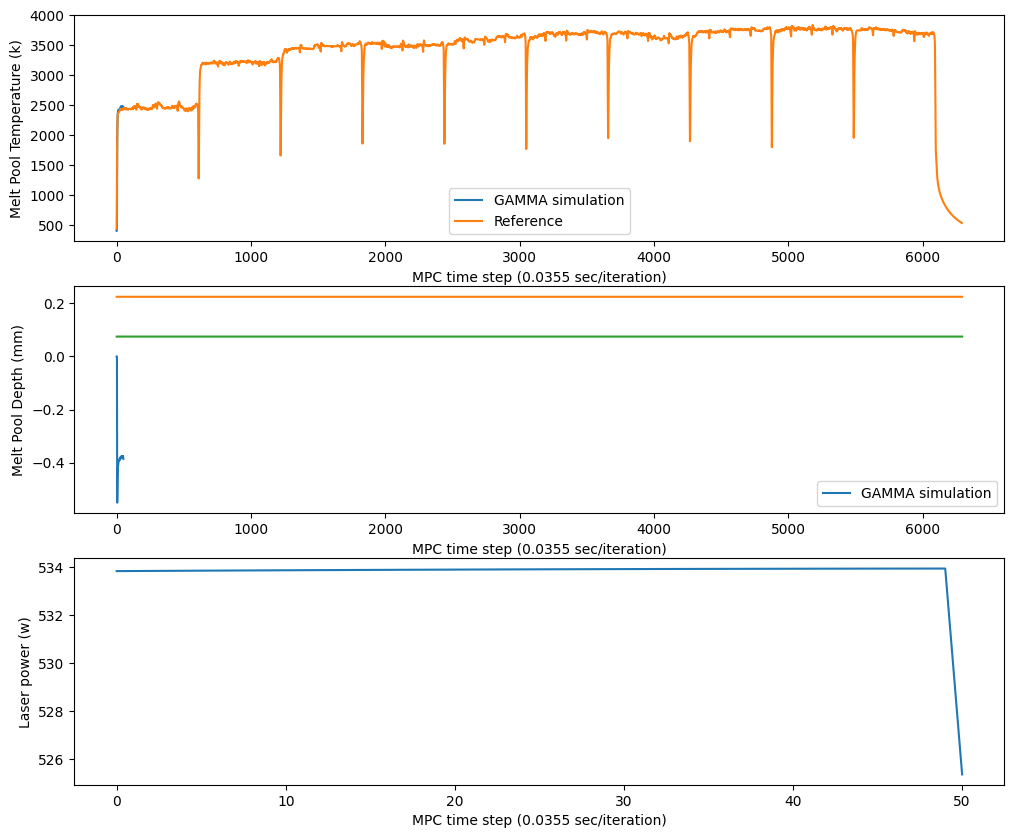

  5%|▍         | 300/6295 [01:10<23:04,  4.33it/s]

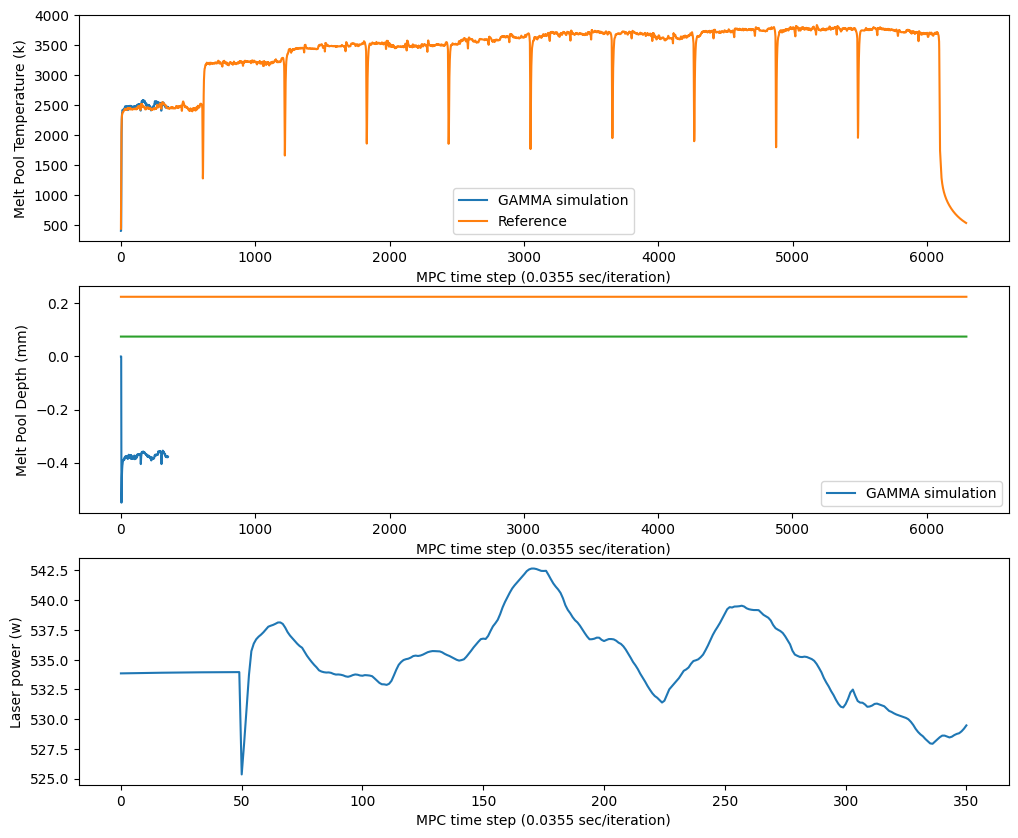

 10%|▉         | 600/6295 [02:22<21:06,  4.50it/s]

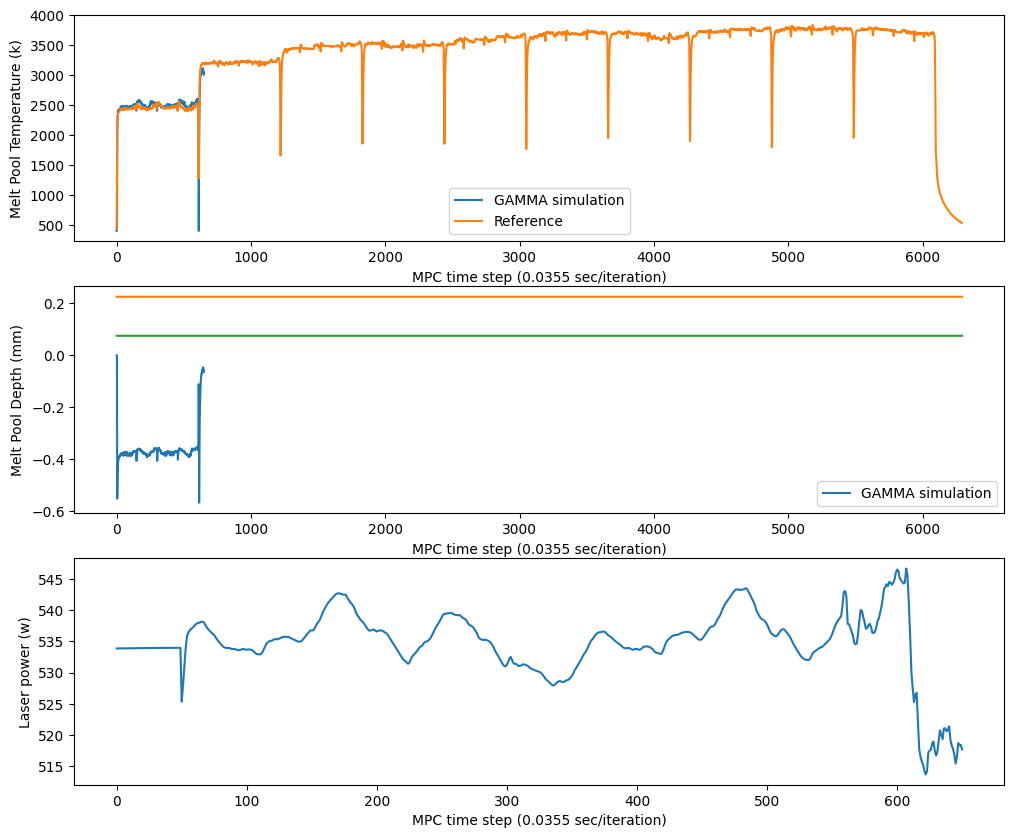

 14%|█▍        | 900/6295 [03:35<21:55,  4.10it/s]

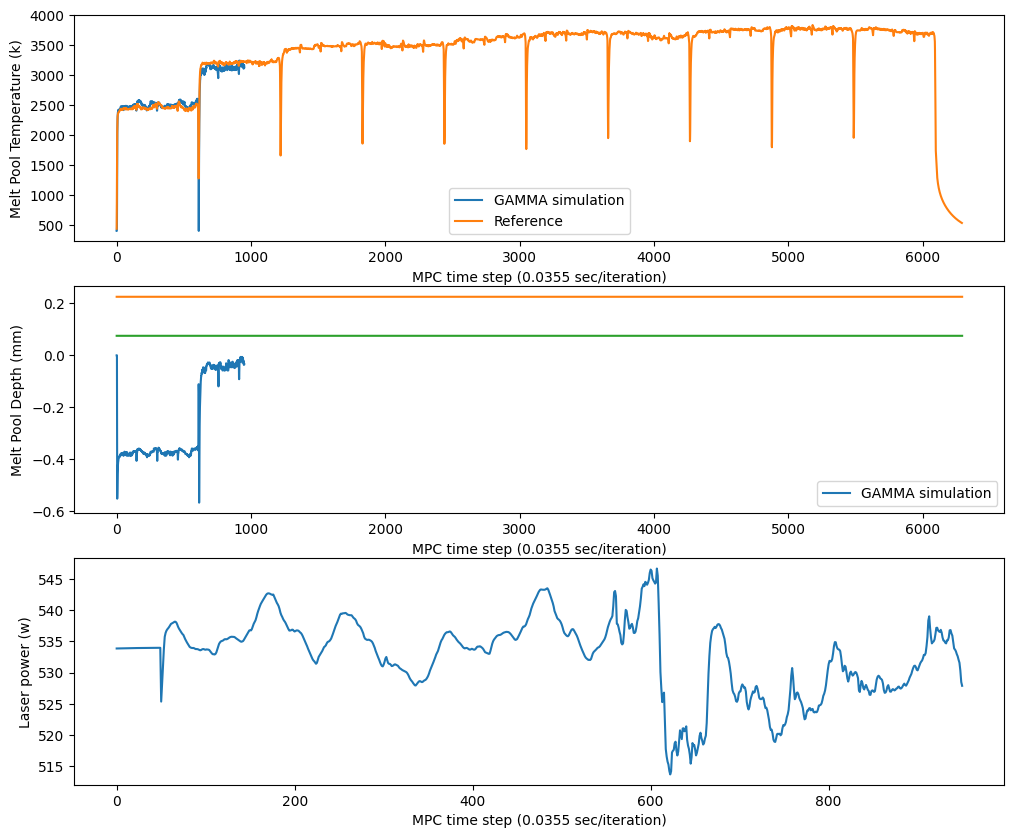

 67%|██████▋   | 4200/6295 [15:48<06:09,  5.67it/s]

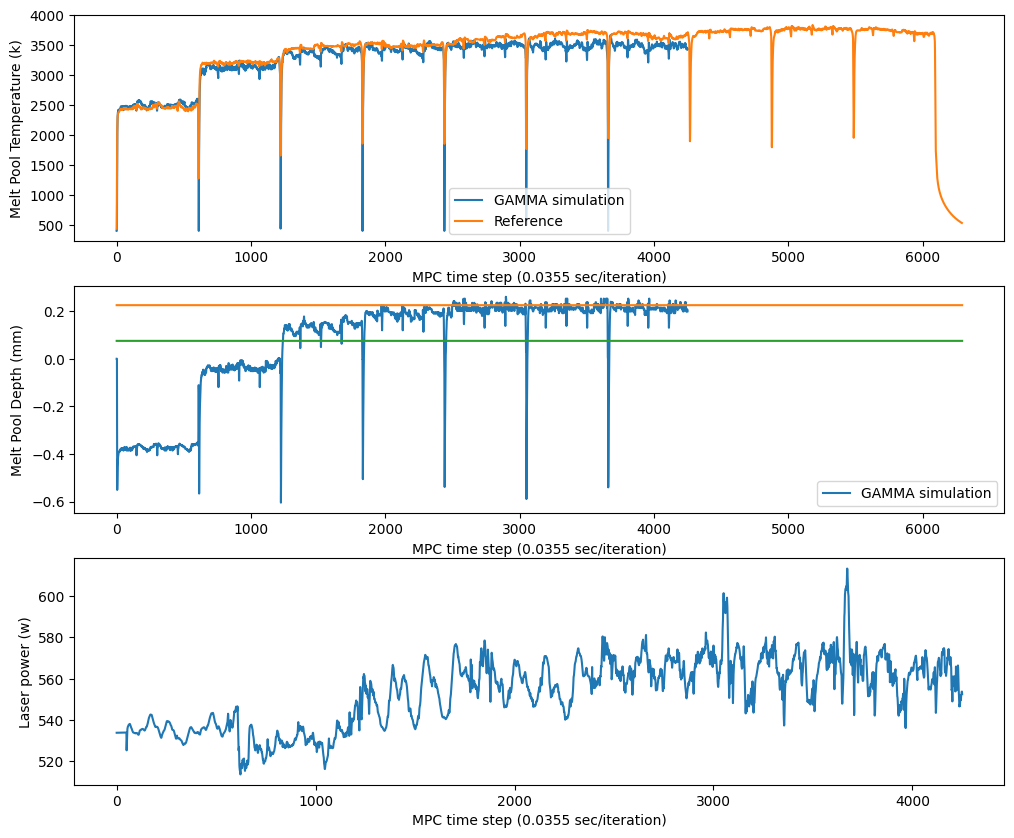

 71%|███████▏  | 4500/6295 [16:37<04:22,  6.85it/s]

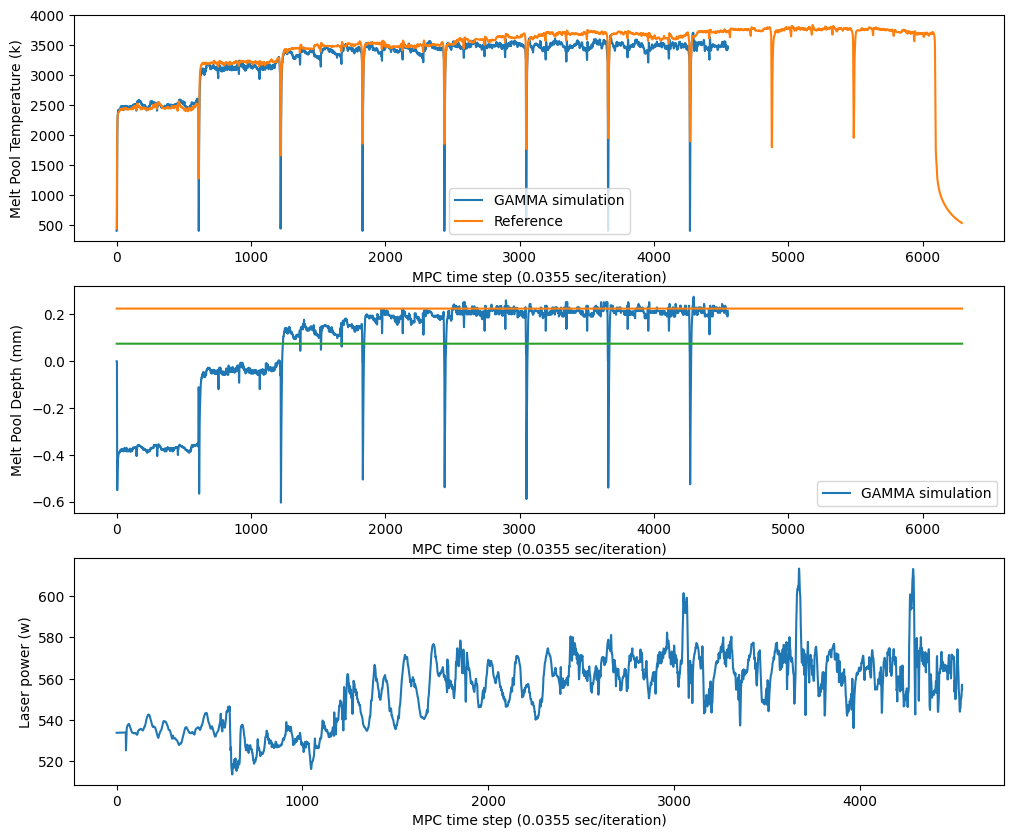

 76%|███████▋  | 4800/6295 [17:25<04:38,  5.36it/s]

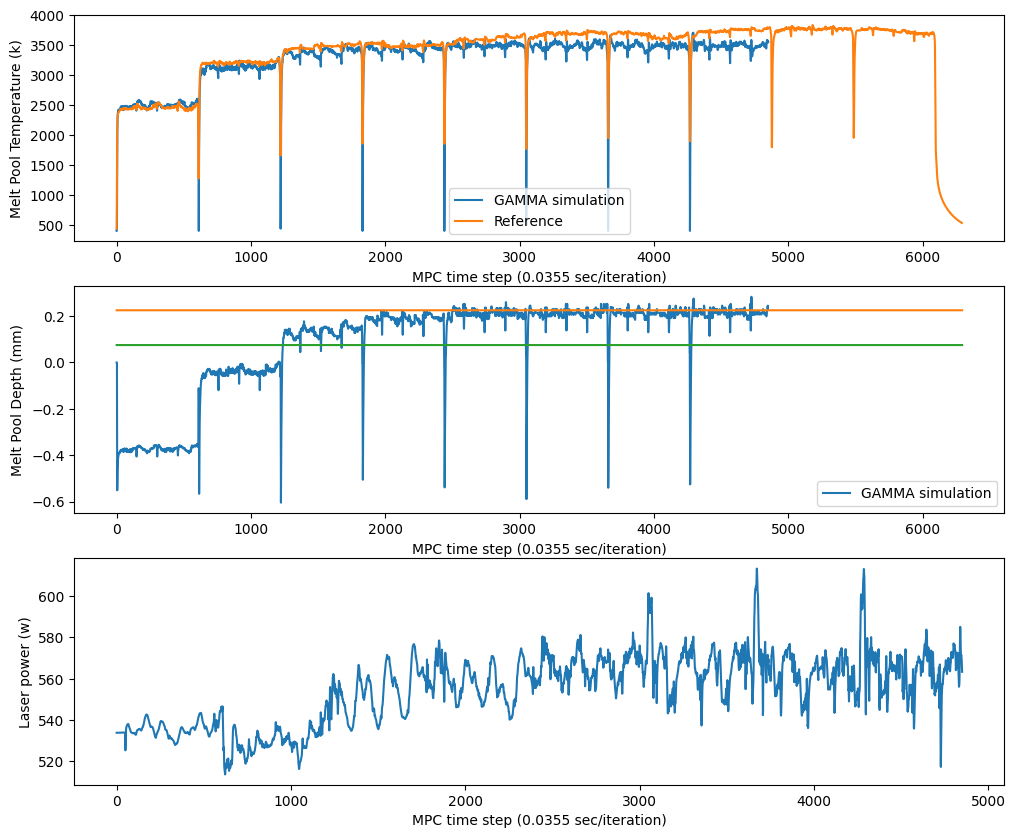

 81%|████████  | 5100/6295 [18:16<03:36,  5.52it/s]

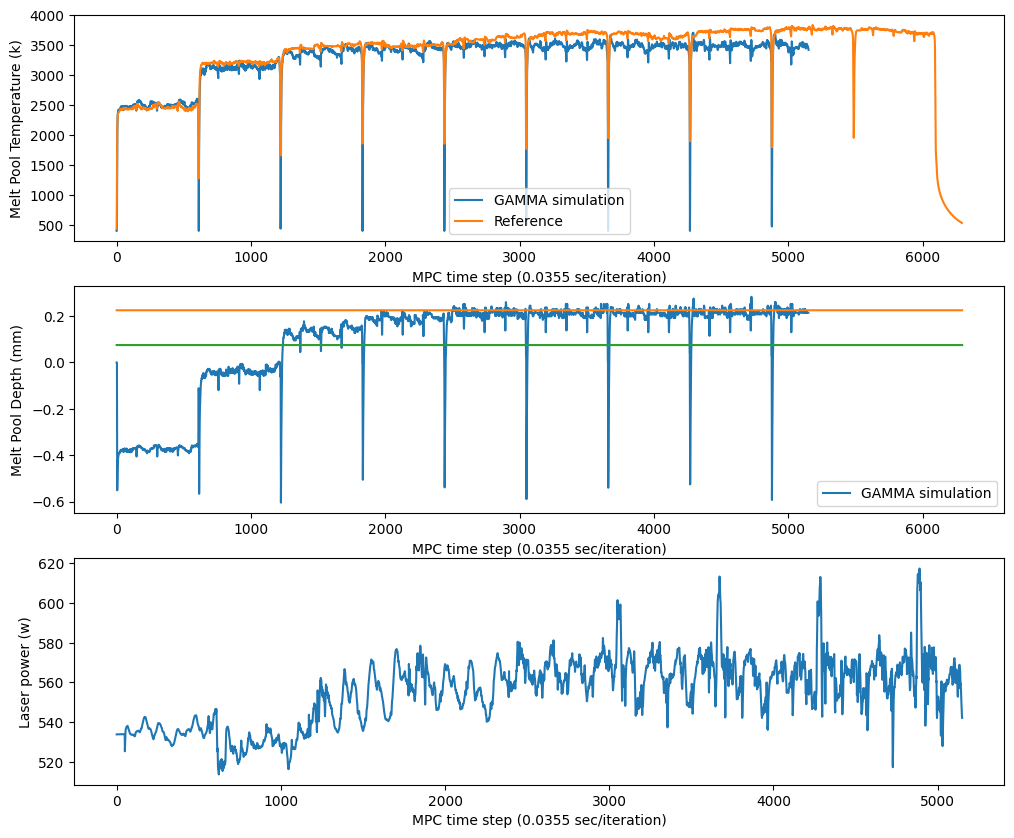

 86%|████████▌ | 5400/6295 [19:05<02:36,  5.71it/s]

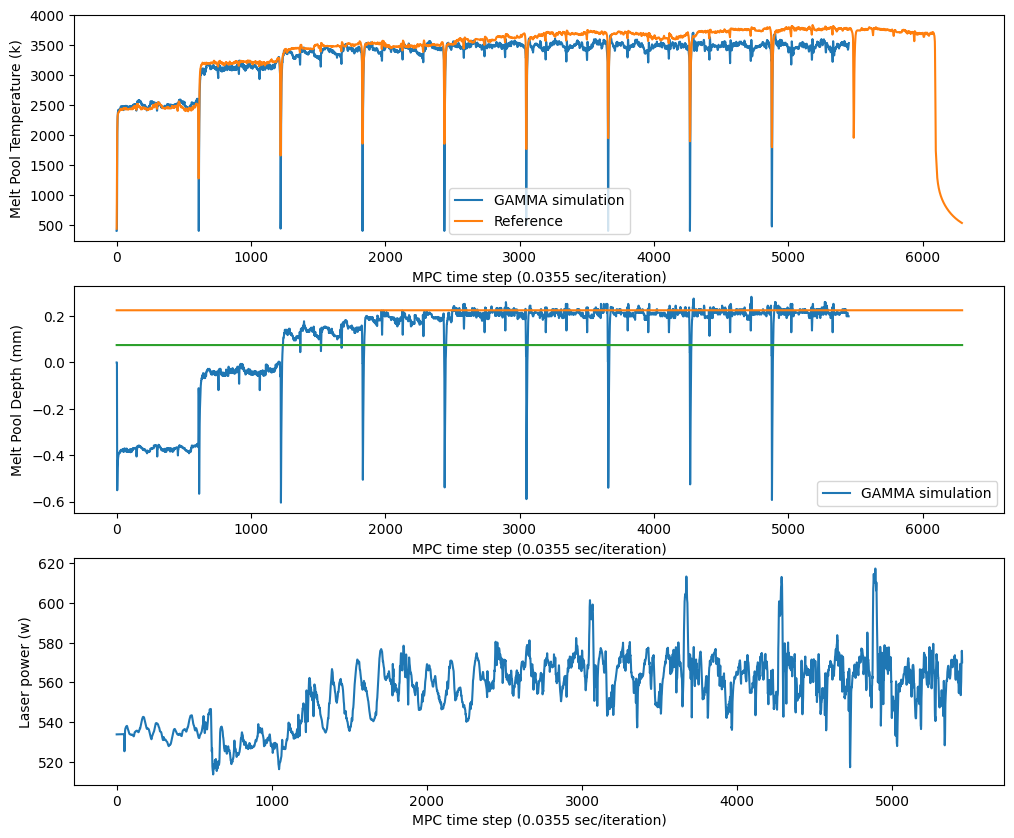

 91%|█████████ | 5700/6295 [19:59<01:48,  5.50it/s]

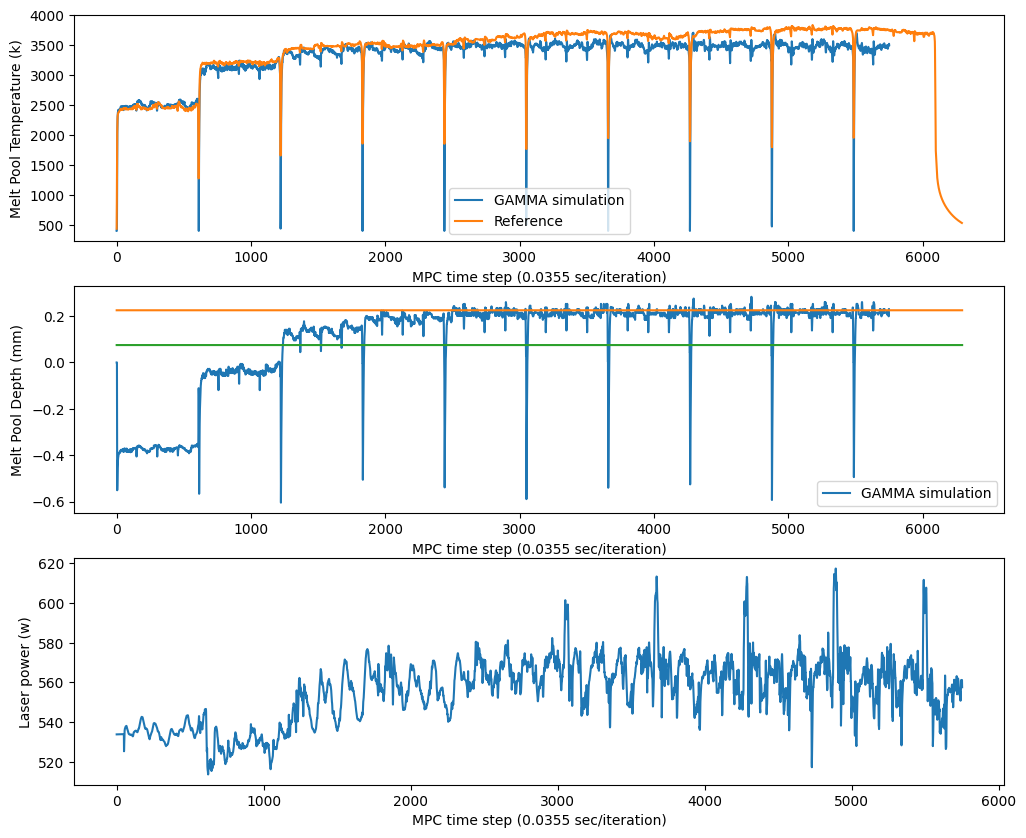

 95%|█████████▌| 6000/6295 [20:52<00:54,  5.45it/s]

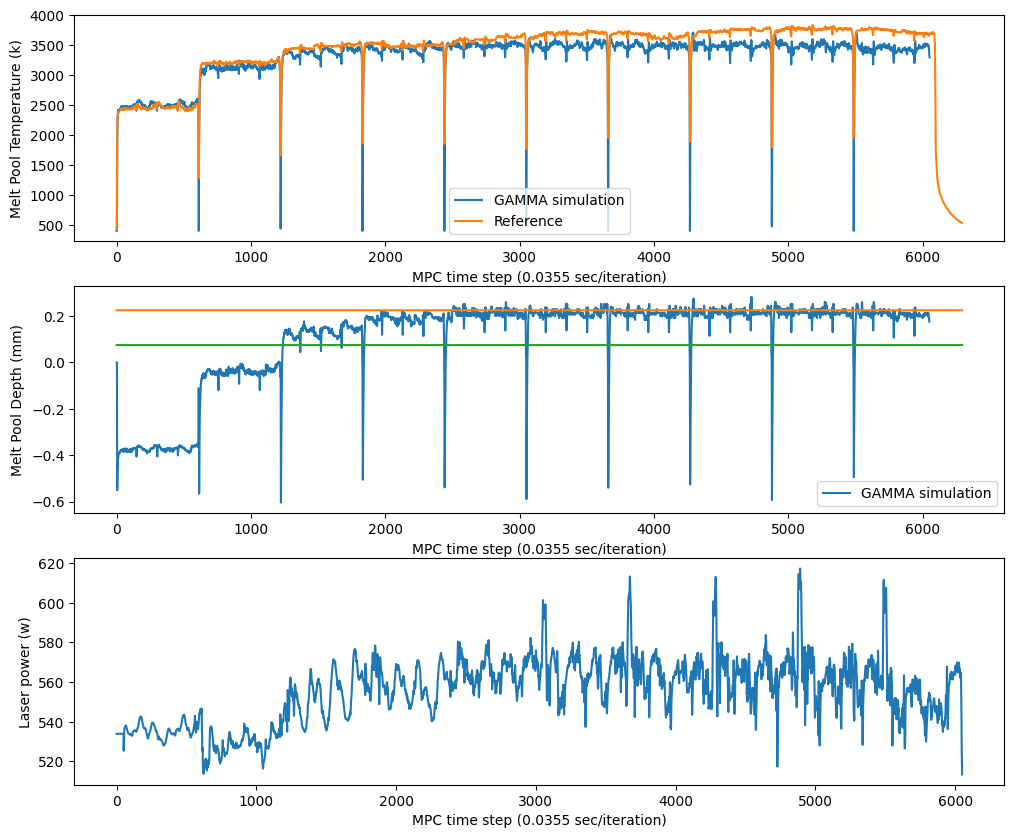

 98%|█████████▊| 6196/6295 [21:24<00:20,  4.82it/s]


RuntimeError: shape '[1, 50, 1]' is invalid for input of size 49

In [14]:
# step #
P = 50
N_step = len(mp_temp_ref) - init_runs + 50

output_dir = "tide_prediction_plots"
os.makedirs(output_dir, exist_ok=True)

# initialize GAMMA class
GAMMA_class.ref = mp_temp_ref
GAMMA_class.fix_cov_all = fix_covariates
GAMMA_class.x_past = init_avg.clone()
GAMMA_class.u_past = laser_power_past.clone()

GAMMA_class.x_hat_current = GAMMA_class.x_past[:, -1]
GAMMA_class.x_sys_current = GAMMA_class.x_past[:, -1].reshape(2, 1)

GAMMA_class.x_past_save = GAMMA_class.x_past.T.clone()
GAMMA_class.u_past_save = GAMMA_class.u_past.clone()
GAMMA_class.MPC_counter = window 

# 추가: TiDE 저장 리스트
tide_temp_all = []
tide_depth_all = []
u_seq_all = []

for i in tqdm(range(N_step)):
    u_pred = run_one_step_policy(GAMMA_class, model, P=P, window=window)

    if 1000 <= i < 4000 and i % 10 == 0:
        tide_temp, tide_depth, u_seq = simulate_policy_horizon_for_visualization(
            GAMMA_obj=GAMMA_class,
            TiDE=TiDE,
            P=P,
            window=window,
            u_pred=u_pred  # ✅ 여기에 u_pred 전달
        )

        # 저장
        tide_temp_all.append(tide_temp)
        tide_depth_all.append(tide_depth)
        u_seq_all.append(u_seq.squeeze(-1))  # ✅ [50,1] → [50] for plotting

        # ✅ 해당 시점에서 시각화 즉시 실행
        plot_fig_with_tide(
            MPC_GAMMA=GAMMA_class,
            N_step=N_step,
            tide_temp_all=[tide_temp],     # 한 스텝만 시각화
            tide_depth_all=[tide_depth],
            u_seq_all=[u_seq_all[-1]],
            start_t=i+50,
            output_dir=output_dir
                                                          # 현재 스텝 기준
        )

    elif i % 300 == 0:
        plot_fig(GAMMA_class, N_step)  # 기존 루틴


In [15]:
import os
import imageio
from tqdm import tqdm

# ── 설정 ────────────────────────────────
folder_path = "/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/tide_prediction_plots"
start_step = 1050
end_step = 4000
step_interval = 10   # 10 간격으로 저장되었을 경우

gif_path = os.path.join(folder_path, "tide_prediction.gif")
mp4_path = os.path.join(folder_path, "tide_prediction.mp4") 

# ── 프레임 리스트 생성 ─────────────────
frames = []

for step in tqdm(range(start_step, end_step + 1, step_interval), desc="Creating GIF"):
    filename = f"tide_plot_step_{step}.png"
    file_path = os.path.join(folder_path, filename)

    if os.path.exists(file_path):
        image = imageio.v2.imread(file_path)
        frames.append(image)
    else:
        print(f"⚠️ Missing: {file_path}")

# ── GIF 저장 ─────────────────────────────
imageio.mimsave(gif_path, frames, duration=1.5)  # duration: 초당 프레임당 시간
imageio.mimsave(mp4_path, frames, fps=5)

print(f"✅ GIF 저장 완료: {gif_path}")


Creating GIF: 100%|██████████| 296/296 [00:20<00:00, 14.49it/s]


✅ GIF 저장 완료: /home/ftk3187/github/DPC_research/02_DED/4_policy_0725/tide_prediction_plots/tide_prediction.gif
